# Script: Work in progress

**Description:** Predict vesselname using Pytorch

**Tested with:** Python 3.11 and Pytorch 2.4.0

**Steps taken:**
- ✅ Prøve å putte emailbody til slutt i strengen <-- tester denne nå.
- ✅ Prøve forskjellige typer ML <-- tester denne nå
- ✅ (ikke bare F1-Score): Given the multi-class nature and potential class imbalance, Matthews Correlation Coefficient (MCC) could provide a more informative evaluation.
    (MCC takes into account true and false positives and negatives across all classes, providing a balanced measure.)
- ✅ Only save model if its the best of that type this far.
- ✅ Save hyperparameters to disk so that it can be given to optuna to avoid same hyperparameters several times in case of crash
- ✅ Flytt filer inn i mapper, eller nummerbasert
- ✅ Apply optuna pruning(hyperband): https://discord.com/channels/878249534336167987/878249534336167993/1288028903171952671


**Next steps:** 
- En ting er hvor bra en modell performer, men hva med hvor ofte den faktisk legger til feil båt. Det er kanskje viktigere.
- Will it help to add owner to the prediction?
- make ascii plots in terminal for each trial - https://stackoverflow.com/questions/20295646/python-ascii-plots-in-terminal
- Lese om pruning: https://broutonlab.com/blog/efficient-hyperparameter-optimization-with-optuna-framework/
- Resume optuna https://optuna.readthedocs.io/en/stable/tutorial/20_recipes/001_rdb.html#rdb

https://chatgpt.com/c/66ec2132-8e78-800a-ae89-1149e22e4ccc

In [1]:
import sys, ctypes as ct
import csv
import pandas as pd
import os

# Read from CSV
os.chdir('/workspace')
csv.field_size_limit(int(ct.c_ulong(-1).value // 2))  # Some lines is too big, so limit had to be changed
df = pd.read_csv('01-dataset_onlyWithImoUntil2023.csv', sep='£', engine='python')



#df2 = df[:10].copy()


In [12]:
df.head()

,Ticket,Queue,Workflow,creation_date,Engineer,RelatedVessel,IMO,HullNr,Owner,VesselType,CustomerRFQNr,ClaimNr,emailBody,emailSubject,Attachments,emailAddresses
0,AZS-66822,Azipod_Support,Azipod_Support,2014-10-29 15:15:11.560,fitihel,NORWEGIAN BREAKAWAY,9606912,678,NCL,NaN,NaN,NaN,"hello slavimir, did service engineer from fact...","breakaway, e256-01203",NaN,hannu.ypya@fi.abb.com cel56@ncl.com chen56@ncl...
1,S-85975,Support,Support,2015-04-09 04:05:43.720,NOEROST,DEEPWATER ORION,9516870,1865,Oceanrig,Floaters,NaN,NaN,hi support marine norway could you please kin...,uer pos 2015acc-0003 mtd temporary loss of po...,NaN,service.marine@sg.abb.com
2,S-364965,Support,Support,2019-09-26 09:26:47.920,noanhan,HERJOLFUR,9825099,70,NaN,NaN,NaN,NaN,"dear sirs, please find attached ship-owner gu...","nb70 guarantee claim no 044 azipull, slow reac...",NB70 claim - nr. 44 Azipull Slow reaction.xlsx,piotr.maras@crist.com.pl geir.holstad@no.abb.c...
3,AZA-474176,Azipod_AfterSales,AfterSales,2021-04-12 10:20:54.297,fikikan1,NORILSKIY NICKEL,9330836,505,NORILSKIY NICKEL,Ice Breakers & Ice Breaking OSV,NaN,NaN,good morning please find attached our po 4500...,norilsk nickel q2020 0603-1 norilsk nickel tbu...,PO 4500226290.pdf,vitaly.petrov@ru.abb.com
4,S-517488,Support_France,Support,2021-12-28 14:13:51.097,frjemes,LACANAU,9377066,015,NaN,NaN,NaN,NaN,dear mr. division we kindly ask you to add you...,request for quotation v-21-lac-326-e/01 for th...,Rfq_V-21-LAC-326-E_01_ABB_France_Marine_Activt...,marie-pascale.lixaute@sea-tankers.fr no-reply@...


In [2]:
# Cleaning of data

# Only keep first 3 email addresses
df['emailAddresses'] = df['emailAddresses'].astype(str).apply(lambda x: ' '.join(x.split()[:3]))
pd.set_option('display.max_colwidth', None)

# Only keep first 3 attachments
df['Attachments'] = df['Attachments'].astype(str).apply(lambda x: ';'.join(x.split(';')[:3]))

# Only keep first 150 and last 150 characters of the subject
df['emailSubject'] = df['emailSubject'].astype(str).apply(lambda x: x[:150] + ' ' + x[-150:])

# if body is over 1000 characters, only keep the first 500 and last 500 characters
df['emailBody'] = df['emailBody'].astype(str).apply(lambda x: x[:500] + ' ' + x[-500:] if len(x) > 1000 else x)

# remove '~', '^', '__' from the columns emailSubject, emailAddresses, Attachments, emailBody
cols_to_clean = ['emailSubject', 'emailAddresses', 'Attachments', 'emailBody']
for col in cols_to_clean:
    df[col] = df[col].astype(str).apply(lambda x: x.replace('~', ''))
    df[col] = df[col].astype(str).apply(lambda x: x.replace('^', ''))
    df[col] = df[col].astype(str).apply(lambda x: x.replace('__', ''))



# Make a new dataframe that we can train on
data = pd.DataFrame()
data['text'] = df['emailSubject'].astype(str) + '~' + df['emailAddresses'].astype(str) + '^' + df['Attachments'].astype(str) + '__' + df['emailBody'].astype(str)
data['text'] = data['text'].str.replace('nan\s*|\s*nan', '', regex=True)                            # remove nan
data['vessel'] = df['IMO'].astype(str) + ' ' + df['RelatedVessel'].astype(str)

#only keep first xxx lines
data = data[:18000].copy()

# Remove rows where the vessel appears only once
vessel_counts = data['vessel'].value_counts()
data = data[data['vessel'].isin(vessel_counts[vessel_counts > 1].index)]

# data['text'] is a string that contains the email subject, email addresses, attachments, and email body, in this format: "subject~addresses^attachments__body"
# data['vessel'] is a string that contains the IMO number and the vessel name, in this format: "IMO vessel_name"


In [18]:
'''
import pandas as pd

#test dataset
data = {'text': ['Email subject for site A~email1@example.com,email2@example.com^file1.pdf,file2.docx__This is the email body for site A',
                 'Email subject for site B~email3@example.com,email4@example.com,email5@example.com^file3.xlsx__This is the email body for site B',
                 'Email subject for site C~email6@example.com^file4.pdf,file5.doc__This is the email body for site C'],
        'site': ['1234567 site A', '7654321 site B', '9876543 site C']
        }

data = pd.DataFrame(data)

data.head()
'''

,text,site
0,"Email subject for site A~email1@example.com,email2@example.com^file1.pdf,file2.docx__This is the email body for site A",1234567 site A
1,"Email subject for site B~email3@example.com,email4@example.com,email5@example.com^file3.xlsx__This is the email body for site B",7654321 site B
2,"Email subject for site C~email6@example.com^file4.pdf,file5.doc__This is the email body for site C",9876543 site C


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    5000 non-null   object
 1   vessel  5000 non-null   object
dtypes: object(2)
memory usage: 78.3+ KB


2024-09-30 21:12:08 - INFO - Starting the training script.
2024-09-30 21:12:11 - INFO - Random seed set to: 42
2024-09-30 21:12:11 - INFO - Data loaded successfully.
2024-09-30 21:12:11 - INFO - Dataset contains 16977 samples.
2024-09-30 21:12:11 - INFO - Columns in the dataset: ['text', 'vessel']
2024-09-30 21:12:11 - INFO - Number of unique labels (vessels): 1643
2024-09-30 21:12:11 - INFO - Training set size: 15279 samples.
2024-09-30 21:12:11 - INFO - Validation set size: 1698 samples.
2024-09-30 21:12:11 - INFO - Using device: cuda
2024-09-30 21:12:11 - INFO - Starting hyperparameter optimization for RNN


/opt/conda/lib/python3.11/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Starting hyperparameter optimization for RNN


[I 2024-09-30 21:12:12,359] Using an existing study with name 'rnn_study' instead of creating a new one.


2024-09-30 21:12:13 - INFO - -------------------------------------------------------------------------------------------------------------------------------
2024-09-30 21:12:13 - INFO - Training RNN model with hyperparameters: {'batch_size': 16, 'num_epochs': 20, 'lr': 0.003005652309243768, 'max_length': 128, 'embed_size': 64, 'hidden_size': 128, 'num_layers': 2}


...

2024-09-30 22:11:12 - INFO - [FASTTEXT] Epoch 18/20, Training Loss: 0.0399, Validation Loss: 1.9783, Accuracy: 0.7155, Precision: 0.6893, Recall: 0.7155, F1-Score: 0.6847, MCC: 0.7151, Time Elapsed: 1m 21s


2024-09-30 22:11:16 - INFO - [FASTTEXT] Epoch 19/20, Training Loss: 0.0342, Validation Loss: 2.0211, Accuracy: 0.7126, Precision: 0.6868, Recall: 0.7126, F1-Score: 0.6817, MCC: 0.7121, Time Elapsed: 1m 25s


2024-09-30 22:11:20 - INFO - [FASTTEXT] Epoch 20/20, Training Loss: 0.0403, Validation Loss: 2.0616, Accuracy: 0.7126, Precision: 0.6895, Recall: 0.7126, F1-Score: 0.6836, MCC: 0.7121, Time Elapsed: 1m 30s
2024-09-30 22:11:20 - INFO - Finished training FASTTEXT model. Total time: 1m 30s
2024-09-30 22:11:20 - INFO - Trial 39 | Model: FASTTEXT | Validation MCC: 0.7121 | F1-Score: 0.6836 | Params: {'batch_size': 16, 'num_epochs': 20, 'lr': 0.008754922571063348, 'max_length': 128, 'embed_size': 256}
Trial 39 | Validation MCC: 0.7121 | F1-Score: 0.6836 | Params: {'batch_size': 16, 'num_epochs': 20, 'lr': 0.008754922571063348, 'max_length': 128, 'embed_size': 256}


[I 2024-09-30 22:11:20,665] Trial 39 finished with value: -0.7121311977120282 and parameters: {'batch_size': 16, 'num_epochs': 20, 'lr': 0.008754922571063348, 'max_length': 128, 'embed_size': 256}. Best is trial 21 with value: -0.7245294159869023.


2024-09-30 22:11:20 - INFO - Best MCC for FASTTEXT: 0.7245
2024-09-30 22:11:20 - INFO - Best hyperparameters: {'batch_size': 16, 'num_epochs': 20, 'lr': 0.0072950194720851555, 'max_length': 128, 'embed_size': 256}
Best MCC for FASTTEXT: 0.7245
Best hyperparameters: {'batch_size': 16, 'num_epochs': 20, 'lr': 0.0072950194720851555, 'max_length': 128, 'embed_size': 256}
2024-09-30 22:11:20 - INFO - Hyperparameter importance for FASTTEXT: {'max_length': 0.5335961687549403, 'lr': 0.23346763848109883, 'embed_size': 0.18499778245238332, 'batch_size': 0.04793841031157755, 'num_epochs': 0.0}
2024-09-30 22:11:20 - INFO - Saved hyperparameter trials to '03-hyperparameter_trials.csv'.
2024-09-30 22:11:21 - INFO - Saved val_accuracy plot to '04-val_accuracy_over_trials.png'.


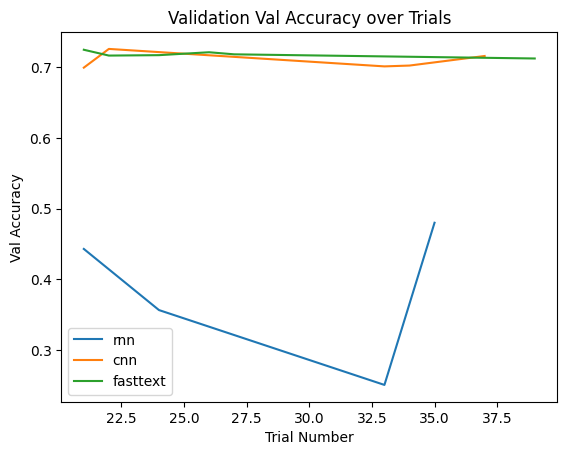

2024-09-30 22:11:21 - INFO - Saved val_f1 plot to '04-val_f1_over_trials.png'.


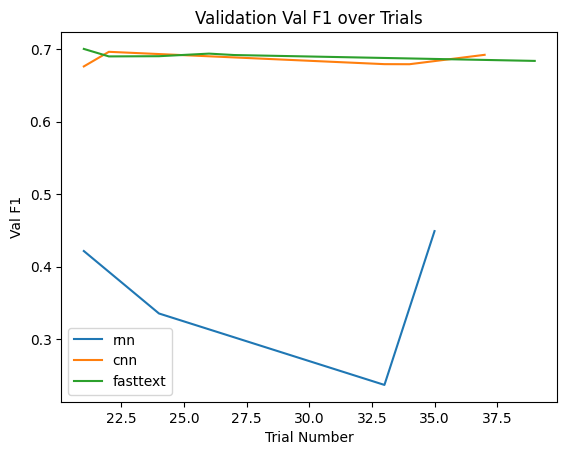

2024-09-30 22:11:21 - INFO - Saved val_mcc plot to '04-val_mcc_over_trials.png'.


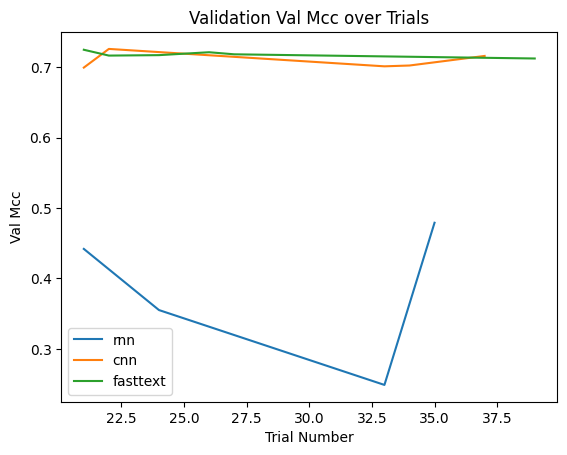

2024-09-30 22:11:21 - INFO - Training script completed.


In [3]:
import torch
from torch.utils.data import DataLoader, TensorDataset
from transformers import BertTokenizerFast, BertForSequenceClassification
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import optuna
import pandas as pd
import logging
from tqdm import tqdm
import time
import sys
import random
import numpy as np
from optuna.pruners import HyperbandPruner
from sklearn.metrics import precision_score, recall_score, f1_score, matthews_corrcoef
import pickle

# Color codes for printing in red
CSTART = '\033[91m'
CEND = '\033[0m'

# ===========================
# SETTINGS
# ===========================
numberOfTrials = 20  # Typically 20
model_list = [
    #'bert',
    'rnn',
    'cnn',
    'fasttext'
]

# Adjusted hyperparameter search space
hyperparameter_search_space = {
    'bert': {
        'batch_size': [16, 32, 64],
        'num_epochs': (20, 20),  # (min, max)
        'lr': (0.00002, 0.00006),  # (min, max)
        'max_length': [128, 256, 512]
    },
    'rnn': {
        'batch_size': [16, 32],
        'num_epochs': (20, 20),  # (min, max)
        'lr': (0.0001, 0.01),  # (min, max)
        'embed_size': [64, 128, 256],
        'hidden_size': [128, 256, 512],
        'num_layers': (1, 3),  # (min, max)
        'max_length': [128, 256, 512]
    },
    'cnn': {
        'batch_size': [16, 32],
        'num_epochs': (20, 20),  # (min, max)
        'lr': (0.0001, 0.01),  # (min, max)
        'embed_size': [64, 128, 256],
        'max_length': [128, 256, 512]
    },
    'fasttext': {
        'batch_size': [16, 32],
        'num_epochs': (20, 20),  # (min, max)
        'lr': (0.0001, 0.01),  # (min, max)
        'embed_size': [64, 128, 256],
        'max_length': [128, 256, 512]
    }
}

# ===========================
# Set up logging
# ===========================
from logging.handlers import RotatingFileHandler

# Create a custom logger
logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)

# Avoid adding handlers multiple times
if not logger.hasHandlers():
    # Create handlers
    handler = RotatingFileHandler('02-training.log', maxBytes=5*1024*1024, backupCount=2)  # 5MB per file, keep 2 backups
    console_handler = logging.StreamHandler(sys.stdout)

    # Create formatters and add them to the handlers
    formatter = logging.Formatter('%(asctime)s - %(levelname)s - %(message)s', datefmt='%Y-%m-%d %H:%M:%S')
    handler.setFormatter(formatter)
    console_handler.setFormatter(formatter)

    # Add handlers to the logger
    logger.addHandler(handler)
    logger.addHandler(console_handler)

# Log initial information
logger.info("Starting the training script.")

# ===========================
# Set random seed for reproducibility
# ===========================
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
logger.info(f"Random seed set to: {seed}")

# ===========================
# Load and preprocess data
# ===========================

# Assuming 'data' is your DataFrame with 'text' and 'vessel' columns
# Ensure that 'data' is properly defined and preprocessed

# Check if 'data' is defined
if 'data' not in globals():
    logger.error("Data is not loaded. Please load your dataset into a DataFrame named 'data'.")
    sys.exit(1)

# Remove any sensitive information from logs
logger.info("Data loaded successfully.")

# Log dataset info
logger.info(f"Dataset contains {len(data)} samples.")
logger.info(f"Columns in the dataset: {data.columns.tolist()}")

# Encode labels
le = LabelEncoder()
data['label'] = le.fit_transform(data['vessel'])
num_labels = len(le.classes_)
logger.info(f"Number of unique labels (vessels): {num_labels}")

# Save label encoder to 'label_encoder.pkl'
with open('05-label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

# Split data into training and validation sets
train_texts, val_texts, train_labels, val_labels = train_test_split(
    data['text'], data['label'], test_size=0.1, random_state=seed, stratify=data['label']
)
logger.info(f"Training set size: {len(train_texts)} samples.")
logger.info(f"Validation set size: {len(val_texts)} samples.")

# Convert labels to NumPy arrays
train_labels = train_labels.to_numpy()
val_labels = val_labels.to_numpy()

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
logger.info(f"Using device: {device}")

# Initialize tokenizer
tokenizer = BertTokenizerFast.from_pretrained('bert-base-uncased')

# Save tokenizer to 'tokenizer.pkl'
with open('05-tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

def encode_texts(texts, labels, tokenizer=None, max_length=256, model_type='bert'):
    if model_type == 'bert':
        # Batch encode the texts
        encoding = tokenizer(
            texts.tolist(),
            add_special_tokens=True,
            truncation=True,
            max_length=max_length,
            padding='max_length',
            return_attention_mask=True,
            return_tensors='pt'
        )
        input_ids = encoding['input_ids']
        attention_masks = encoding['attention_mask']
        labels = torch.tensor(labels)
        return TensorDataset(input_ids, attention_masks, labels)
    else:
        # For other models, handle tokenization differently
        input_ids = []
        for text in texts:
            tokens = tokenizer.encode(
                text,
                add_special_tokens=True,
                truncation=True,
                max_length=max_length
            )
            token_ids = tokens + [0] * (max_length - len(tokens))
            input_ids.append(token_ids)
        input_ids = torch.tensor(input_ids)
        labels = torch.tensor(labels)
        return TensorDataset(input_ids, labels)

def train_model(trial, model_name, train_texts, train_labels, val_texts, val_labels, num_labels, tokenizer, params, best_metric_so_far=None):
    start_time = time.time()
    # Use hyperparameters from 'params' dictionary
    batch_size = params.get('batch_size', 16)
    num_epochs = params.get('num_epochs', 3)
    lr = params.get('lr', 1e-3)
    embed_size = params.get('embed_size', 128)
    hidden_size = params.get('hidden_size', 128)
    num_layers = params.get('num_layers', 2)
    max_length = params.get('max_length', 256)

    # Log hyperparameters
    logger.info(f"-------------------------------------------------------------------------------------------------------------------------------")
    logger.info(f"Training {model_name.upper()} model with hyperparameters: {params}")

    try:
        if model_name == 'bert':
            model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=num_labels)
            model_type = 'bert'
        elif model_name == 'rnn':
            class RNNClassifier(nn.Module):
                def __init__(self, vocab_size, embed_size, hidden_size, num_layers, num_classes):
                    super(RNNClassifier, self).__init__()
                    self.embedding = nn.Embedding(vocab_size, embed_size)
                    self.lstm = nn.LSTM(embed_size, hidden_size, num_layers, batch_first=True)
                    self.fc = nn.Linear(hidden_size, num_classes)
                def forward(self, x):
                    x = self.embedding(x)
                    h_0 = torch.zeros(num_layers, x.size(0), hidden_size).to(device)
                    c_0 = torch.zeros(num_layers, x.size(0), hidden_size).to(device)
                    out, _ = self.lstm(x, (h_0, c_0))
                    out = self.fc(out[:, -1, :])
                    return out
            vocab_size = tokenizer.vocab_size
            model = RNNClassifier(vocab_size, embed_size, hidden_size, num_layers, num_labels)
            model_type = 'other'
        elif model_name == 'cnn':
            class CNNClassifier(nn.Module):
                def __init__(self, vocab_size, embed_size, num_classes):
                    super(CNNClassifier, self).__init__()
                    self.embedding = nn.Embedding(vocab_size, embed_size)
                    self.conv1 = nn.Conv2d(1, 100, (3, embed_size))
                    self.fc = nn.Linear(100, num_classes)
                def forward(self, x):
                    x = self.embedding(x).unsqueeze(1)
                    x = self.conv1(x).squeeze(3)
                    x = nn.functional.relu(x)
                    x = nn.functional.max_pool1d(x, x.size(2)).squeeze(2)
                    x = self.fc(x)
                    return x
            vocab_size = tokenizer.vocab_size
            model = CNNClassifier(vocab_size, embed_size, num_labels)
            model_type = 'other'
        elif model_name == 'fasttext':
            class FastTextClassifier(nn.Module):
                def __init__(self, vocab_size, embed_size, num_classes):
                    super(FastTextClassifier, self).__init__()
                    self.embedding = nn.Embedding(vocab_size, embed_size)
                    self.fc = nn.Linear(embed_size, num_classes)
                def forward(self, x):
                    x = self.embedding(x)
                    x = x.mean(dim=1)
                    x = self.fc(x)
                    return x
            vocab_size = tokenizer.vocab_size
            model = FastTextClassifier(vocab_size, embed_size, num_labels)
            model_type = 'other'
        else:
            raise ValueError(f"Unknown model name: {model_name}")

        model.to(device)

        # Prepare data loaders
        train_dataset = encode_texts(train_texts, train_labels, tokenizer, max_length=max_length, model_type=model_type)
        val_dataset = encode_texts(val_texts, val_labels, tokenizer, max_length=max_length, model_type=model_type)

        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

        # Define optimizer and loss function
        if model_name == 'bert':
            optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
            criterion = None  # BERT uses its own loss function
        else:
            optimizer = optim.Adam(model.parameters(), lr=lr)
            criterion = nn.CrossEntropyLoss()

        # Training loop
        train_losses = []
        val_losses = []
        val_accuracies = []
        val_precisions = []
        val_recalls = []
        val_f1s = []
        val_mccs = []

        for epoch in range(num_epochs):
            model.train()
            total_train_loss = 0

            # Training progress bar
            train_iterator = tqdm(train_loader, desc=f"Training Epoch {epoch + 1}/{num_epochs}", leave=False)
            for batch in train_iterator:
                optimizer.zero_grad()
                if model_type == 'bert':
                    input_ids = batch[0].to(device)
                    attention_mask = batch[1].to(device)
                    labels = batch[2].to(device)
                    outputs = model(
                        input_ids=input_ids,
                        attention_mask=attention_mask,
                        labels=labels
                    )
                    loss = outputs.loss
                else:
                    input_ids = batch[0].to(device)
                    labels = batch[1].to(device)
                    outputs = model(input_ids)
                    loss = criterion(outputs, labels)

                total_train_loss += loss.item()
                loss.backward()
                optimizer.step()

                # Update progress bar description
                train_iterator.set_postfix(loss=loss.item())

            avg_train_loss = total_train_loss / len(train_loader)
            train_losses.append(avg_train_loss)

            # Validation loop
            model.eval()
            total_val_loss = 0
            correct_predictions = 0
            total_predictions = 0
            all_preds = []
            all_labels_list = []

            val_iterator = tqdm(val_loader, desc=f"Validation Epoch {epoch + 1}/{num_epochs}", leave=False)
            with torch.no_grad():
                for batch in val_iterator:
                    if model_type == 'bert':
                        input_ids = batch[0].to(device)
                        attention_mask = batch[1].to(device)
                        labels = batch[2].to(device)
                        outputs = model(
                            input_ids=input_ids,
                            attention_mask=attention_mask,
                            labels=labels
                        )
                        loss = outputs.loss
                        logits = outputs.logits
                    else:
                        input_ids = batch[0].to(device)
                        labels = batch[1].to(device)
                        outputs = model(input_ids)
                        loss = criterion(outputs, labels)
                        logits = outputs

                    total_val_loss += loss.item()
                    preds = torch.argmax(logits, dim=1)
                    correct_predictions += torch.sum(preds == labels)
                    total_predictions += labels.size(0)

                    all_preds.extend(preds.cpu().numpy())
                    all_labels_list.extend(labels.cpu().numpy())

                    # Update progress bar description
                    val_iterator.set_postfix(loss=loss.item())

            avg_val_loss = total_val_loss / len(val_loader)
            val_accuracy = correct_predictions.double() / total_predictions
            val_losses.append(avg_val_loss)
            val_accuracies.append(val_accuracy.item())

            # Calculate metrics
            val_precision = precision_score(all_labels_list, all_preds, average='weighted', zero_division=0)
            val_recall = recall_score(all_labels_list, all_preds, average='weighted', zero_division=0)
            val_f1 = f1_score(all_labels_list, all_preds, average='weighted', zero_division=0)
            val_mcc = matthews_corrcoef(all_labels_list, all_preds)
            val_precisions.append(val_precision)
            val_recalls.append(val_recall)
            val_f1s.append(val_f1)
            val_mccs.append(val_mcc)

            epoch_time = time.time() - start_time

            # Logging progress for each epoch
            logger.info(f"[{model_name.upper()}] Epoch {epoch + 1}/{num_epochs}, "
                        f"Training Loss: {avg_train_loss:.4f}, Validation Loss: {avg_val_loss:.4f}, "
                        f"Accuracy: {val_accuracy:.4f}, Precision: {val_precision:.4f}, "
                        f"Recall: {val_recall:.4f}, F1-Score: {val_f1:.4f}, MCC: {val_mcc:.4f}, Time Elapsed: {epoch_time//60:.0f}m {epoch_time%60:.0f}s")

            # Report intermediate objective value to Optuna
            trial.report(-val_mcc, step=epoch)

            # Handle pruning
            if trial.should_prune():
                logger.info(f"Trial {trial.number} pruned at epoch {epoch + 1}")
                raise optuna.exceptions.TrialPruned()

        total_time = time.time() - start_time
        logger.info(f"Finished training {model_name.upper()} model. Total time: {total_time//60:.0f}m {total_time%60:.0f}s")

        # Determine if current model is better than the best so far
        current_metric = val_mccs[-1]

        save_model = False
        if best_metric_so_far is None or current_metric > best_metric_so_far:
            best_metric_so_far = current_metric
            save_model = True

        if save_model:
            # Save the model checkpoint
            model_save_path = f"05-{model_name}_best_model.pt"
            torch.save(model.state_dict(), model_save_path)
            
            # Save the hyperparameters
            hyperparams_save_path = f"05-{model_name}_best_hyperparams.pkl"
            with open(hyperparams_save_path, 'wb') as f:
                pickle.dump(params, f)
            
            logger.info(f"Saved best {model_name.upper()} model to '{model_save_path}' with MCC: {current_metric:.4f}")


        # Return performance metrics and best_metric_so_far
        return {
            'model_name': model_name,
            'train_losses': train_losses,
            'val_losses': val_losses,
            'val_accuracies': val_accuracies,
            'val_precisions': val_precisions,
            'val_recalls': val_recalls,
            'val_f1s': val_f1s,
            'val_mccs': val_mccs,
            'params': params,
            'best_metric_so_far': best_metric_so_far
        }

    except optuna.exceptions.TrialPruned as e:
        logger.info(f"Trial {trial.number} pruned at epoch {epoch + 1}")
        raise e  # Re-raise the exception to notify Optuna

    except Exception as e:
        logger.error(f"An error occurred during training: {e}")
        raise e  # Re-raise the exception after logging

study_results = {}
all_trials = []

# Dictionary to keep track of the best metric for each model
best_metrics = {model_name: None for model_name in model_list}

for model_name in model_list:
    logger.info(f"Starting hyperparameter optimization for {model_name.upper()}")
    print(f"Starting hyperparameter optimization for {model_name.upper()}")

    # Configure the pruner
    pruner = HyperbandPruner(
        min_resource=1,
        max_resource=20,  # Should match the maximum num_epochs
        reduction_factor=3
    )

    # Use an SQLite database to store the study
    study_name = f"{model_name}_study"
    storage_name = f"sqlite:///02-optuna.db"
    study = optuna.create_study(
        direction='minimize',
        pruner=pruner,
        storage=storage_name,
        study_name=study_name,
        load_if_exists=True
    )

    # Optimize
    def objective(trial):
        # Define hyperparameter search space
        params = {}
        search_space = hyperparameter_search_space[model_name]

        params['batch_size'] = trial.suggest_categorical('batch_size', search_space['batch_size'])
        params['num_epochs'] = trial.suggest_int('num_epochs', search_space['num_epochs'][0], search_space['num_epochs'][1])
        params['lr'] = trial.suggest_float('lr', search_space['lr'][0], search_space['lr'][1], log=True)
        params['max_length'] = trial.suggest_categorical('max_length', search_space['max_length'])

        if model_name != 'bert':
            params['embed_size'] = trial.suggest_categorical('embed_size', search_space['embed_size'])
            if model_name == 'rnn':
                params['hidden_size'] = trial.suggest_categorical('hidden_size', search_space['hidden_size'])
                params['num_layers'] = trial.suggest_int('num_layers', search_space['num_layers'][0], search_space['num_layers'][1])

        # Get the best metric so far for this model
        best_metric_so_far = best_metrics[model_name]

        # Call the train_model function, passing the trial
        result = train_model(
            trial,
            model_name,
            train_texts,
            train_labels,
            val_texts,
            val_labels,
            num_labels,
            tokenizer,
            params,
            best_metric_so_far
        )

        # Update the best metric for this model
        best_metrics[model_name] = result['best_metric_so_far']

        # Get the last validation MCC
        val_mcc = result['val_mccs'][-1]
        val_f1 = result['val_f1s'][-1]

        # Store the F1 score as a trial attribute in the database
        trial.set_user_attr('val_f1', val_f1)

        # Store trial results
        trial_result = {
            'model_name': model_name,
            'trial_number': trial.number,
            'val_accuracy': result['val_accuracies'][-1],
            'val_f1': result['val_f1s'][-1],
            'val_mcc': val_mcc,
            'params': params
        }
        all_trials.append(trial_result)

        # Log progress for each trial
        logger.info(f"Trial {trial.number} | Model: {model_name.upper()} | Validation MCC: {val_mcc:.4f} | F1-Score: {val_f1:.4f} | Params: {params}")
        print(f"Trial {trial.number} | Validation MCC: {CSTART}{val_mcc:.4f}{CEND} | F1-Score: {CSTART}{val_f1:.4f}{CEND} | Params: {params}")

        return -val_mcc  # Return negative MCC for minimization

    study.optimize(objective, n_trials=numberOfTrials)  # n_trials = how many trials to run for each model

    # Store the best hyperparameters and the best score
    best_trial = study.best_trial
    study_results[model_name] = {
        'best_params': best_trial.params,
        'best_value': -best_trial.value  # Convert back to positive MCC
    }

    logger.info(f"Best MCC for {model_name.upper()}: {-best_trial.value:.4f}")
    logger.info(f"Best hyperparameters: {best_trial.params}")
    print(f"Best MCC for {model_name.upper()}: {-best_trial.value:.4f}")
    print(f"Best hyperparameters: {best_trial.params}")

    # Optional: Log hyperparameter importance
    importance = optuna.importance.get_param_importances(study)
    logger.info(f"Hyperparameter importance for {model_name.upper()}: {importance}")

# Convert all_trials to a DataFrame
trials_df = pd.DataFrame(all_trials)

# Normalize parameters for storage
trials_df['params'] = trials_df['params'].apply(lambda x: str(x))

# Save to CSV
trials_df.to_csv('03-hyperparameter_trials.csv', index=False)
logger.info("Saved hyperparameter trials to '03-hyperparameter_trials.csv'.")

# Visualize results
for metric in ['val_accuracy', 'val_f1', 'val_mcc']:
    plt.figure()
    for model_name in model_list:
        model_trials = trials_df[trials_df['model_name'] == model_name]
        plt.plot(model_trials['trial_number'], model_trials[metric], label=model_name)
    plt.title(f"Validation {metric.replace('_', ' ').title()} over Trials")
    plt.xlabel('Trial Number')
    plt.ylabel(metric.replace('_', ' ').title())
    plt.legend()
    plot_filename = f'04-{metric}_over_trials.png'
    plt.savefig(plot_filename)
    logger.info(f"Saved {metric} plot to '{plot_filename}'.")
    plt.show()

logger.info("Training script completed.")

# unix command to start optuna dashboard is: optuna-dashboard sqlite:///02-optuna.db


In [20]:
# SLETT
import sqlite3
import os

# Set current directory to /workspace/
os.chdir('/workspace')
current_dir = os.getcwd()
print(f"Current directory: {current_dir}")

# Delete the optuna.db file if it already exists
if os.path.exists('optuna.db'):
    os.remove('optuna.db')
    print("Deleted existing 'optuna.db' file.")

# Get all SQLite files in the current directory, excluding the target 'optuna.db' if it already exists
sqlite_files = [f for f in os.listdir(current_dir) if f.endswith('.db') and f != 'optuna.db']
print(f"Found {len(sqlite_files)} SQLite files in the current directory.")

# Connect to the target database (creates optuna.db if it doesn't exist)
target_db_path = os.path.join(current_dir, 'optuna.db')
conn = sqlite3.connect(target_db_path)
cursor = conn.cursor()

# Loop through all SQLite files
for file in sqlite_files:
    file_path = os.path.join(current_dir, file)
    print('\n')
    print(f"Processing file: {file}")
    
    # Connect to the current database
    conn2 = sqlite3.connect(file_path)
    cursor2 = conn2.cursor()

    # Get the list of tables in the current database
    cursor2.execute("SELECT name FROM sqlite_master WHERE type='table'")
    tables = cursor2.fetchall()

    # Loop over each table and copy its contents to the target database
    for table in tables:
        table_name = table[0]

        # Check if the table already exists in the target database
        cursor.execute(f"SELECT name FROM sqlite_master WHERE type='table' AND name='{table_name}'")
        if cursor.fetchone() is None:
            # Create the table in the target database if it doesn't exist
            cursor2.execute(f"SELECT sql FROM sqlite_master WHERE type='table' AND name='{table_name}'")
            print(f"Creating table: {table_name}")
            create_table_sql = cursor2.fetchone()[0]
            cursor.execute(create_table_sql)

        # Copy the data from the current table into the target database
        cursor2.execute(f"SELECT * FROM {table_name}")
        rows = cursor2.fetchall()
        if rows:
            print(f"    Inserting data into table: {table_name}")
            # Get column names from the table to ensure the insert is accurate
            cursor2.execute(f"PRAGMA table_info({table_name})")
            column_names = [info[1] for info in cursor2.fetchall()]
            columns = ', '.join(column_names)
            placeholders = ', '.join(['?'] * len(column_names))

            # Use INSERT OR IGNORE to avoid duplicate primary key errors
            cursor.executemany(f"INSERT OR IGNORE INTO {table_name} ({columns}) VALUES ({placeholders})", rows)

    # Commit and close the current database
    conn.commit()
    conn2.close()

# Close the target database connection
conn.close()

print("Databases merged successfully into 'optuna.db'.")


Current directory: /workspace
Deleted existing 'optuna.db' file.
Found 4 SQLite files in the current directory.


Processing file: bert_study.db
Creating table: studies
    Inserting data into table: studies
Creating table: version_info
    Inserting data into table: version_info
Creating table: study_directions
    Inserting data into table: study_directions
Creating table: study_user_attributes
Creating table: study_system_attributes
Creating table: trials
    Inserting data into table: trials
Creating table: trial_user_attributes
Creating table: trial_system_attributes
Creating table: trial_params
    Inserting data into table: trial_params
Creating table: trial_values
    Inserting data into table: trial_values
Creating table: trial_intermediate_values
Creating table: trial_heartbeats
Creating table: alembic_version
    Inserting data into table: alembic_version


Processing file: cnn_study.db
    Inserting data into table: studies
    Inserting data into table: version_info
    In

### Testing model:

In [4]:
# Test with emails not in the training dataset


# Read from CSV
import ctypes as ct
import os
import csv
import pandas as pd

os.chdir('/workspace')
csv.field_size_limit(int(ct.c_ulong(-1).value // 2))  # Some lines is too big, so limit had to be changed
df = pd.read_csv('01-dataset_onlyWithImoFrom2023.csv', sep='£', engine='python')

df.head()

,Ticket,Queue,Workflow,creation_date,Engineer,RelatedVessel,IMO,HullNr,Owner,VesselType,CustomerRFQNr,ClaimNr,emailBody,emailSubject,Attachments,emailAddresses
0,A-607751,AfterSales,AfterSales,2023-02-28 10:55:15.360,nojugje,OCEAN GREATWHITE,9697569,2704,Diamond Offshore,NaN,138-114852,NaN,"-original message- from: rcrockart@dodi.com sent: mandag 27. februar 2023 16:40 to: claudiomiro campos cc: rcrockart@dodi.com subject: rfq attached contains 1 fr(s) - 138-114852a please provide your competitive quotation (including price, availability, fob and validity) on the attached item(s). e-mail your response to rcrockart@dodi.com or fax it to my attention at . if you have any questions, feel free to phone me at . your prompt response is appreciated.",rfq attached contains 1 fr(s) 138-114852a,1.pdf,claudiomiro.campos@no.abb.com
1,OS-615335,Octopus_Support,Octopus_Support,2023-04-01 22:08:43.917,nlmaeil,CMA CGM MARSEILLE,9709207,4093,NaN,NaN,NaN,NaN,"good evening i am onboard the vessel cma cgm marseille to install new it solution and needs the url to be used for deactivation of the current installation onboard. best regards nils arve vikanes field engineer marlink as meatjønnsvegen 74 5412 stord – norway t: +47 4000 1819 m:+47 9096 8794 e: nils.arve.vikanes@marlink.com marlink, the pioneer in business critical communication solutions that customers can rely on. for more information, visit www.marlink.com and follow us on facebook , twitter , linkedin and youtube . this message and any attachments are confidential to the company and intended solely for the individual(s) or entity to which it is addressed. if you are not the intended recipient, do not read, copy or distribute the email or any attachments. please notify the sender immediately by return e-mail.",migration of octopus to new computer on cma cgm marseille,NaN,nils.arve.vikanes@marlink.com nl-advisory-support@abb.com
2,A-614263,AfterSales_USA_Miami,AfterSales,2023-03-28 11:29:14.267,usjepar25,WEST AURIGA,9609392,1911,NaN,Floaters,NaN,NaN,"good morning, i am trying to source the bracket which connects the supply unit cooling fan (cubicle er 205) to the inverter. i have not been able to find a part number for it. pictures of the bracket are attached, please let me know if any more information is needed. thanks, jed fortenberry et - auriga diamond offshore bridge: +1 (713) 693-1290",dsu cooling fan mounting bracket,image1.jpeg;image0.jpeg,auriga_et@dodi.com spareparts.marine@us.abb.com auriga_electsupt@dodi.com
3,A-612524,AfterSales_USA_Miami,AfterSales,2023-03-20 16:15:12.373,usyosan,NORWEGIAN PEARL,9342281,669,NCL,Cruise,PRL10230191,NaN,"new rfq prl10230191 from ncl (bahamas) ltd. for vessel norwegian pearl new rfq received from ncl (bahamas) ltd. for vessel norwegian pearl respond to rfq m-633-sce/jf=hydac heat exchanger from: ncl (bahamas) ltd. (tn-13116) rfq ref: prl10230191 quote by: buyer vessel rfq ref quote by sent to contact ncl (bahamas) ltd. (tn-13116) norwegian pearl (9342281) prl10230191 not set abb inc. (tn-74799) - - [port: apollo export warehouse, ] respond to rfq browser requirements: chrome version 80 or later is recommended shipserv.com this email and any attachments are sent in confidence and are not intended to be read and/or relied on by any person other than the intended recipient. the recipient is responsible for conducting the appropriate virus checks and while shipserv have put every effort into ensuring the message is secure, we give no warranty, (express or implied), that this email is free of viruses or that its transmission has been secure. if you receive this email by mistake, please reply to this message and then delete it. any use, copying or dissemination of this email or any information contained in it to anyone other than an intended recipient is prohibited. any and all communications sent to us may be monitored and/or stored by us to ensure compliance with relevant legislation, rules and policies. all communications are handled in full compl

In [5]:
# Cleaning of data

# Only keep first 3 email addresses
df['emailAddresses'] = df['emailAddresses'].astype(str).apply(lambda x: ' '.join(x.split()[:3]))
pd.set_option('display.max_colwidth', None)

# Only keep first 3 attachments
df['Attachments'] = df['Attachments'].astype(str).apply(lambda x: ';'.join(x.split(';')[:3]))

# Only keep first 150 and last 150 characters of the subject
df['emailSubject'] = df['emailSubject'].astype(str).apply(lambda x: x[:150] + ' ' + x[-150:])

# if body is over 1000 characters, only keep the first 500 and last 500 characters
df['emailBody'] = df['emailBody'].astype(str).apply(lambda x: x[:500] + ' ' + x[-500:] if len(x) > 1000 else x)

# remove '~', '^', '__' from the columns emailSubject, emailAddresses, Attachments, emailBody
cols_to_clean = ['emailSubject', 'emailAddresses', 'Attachments', 'emailBody']
for col in cols_to_clean:
    df[col] = df[col].astype(str).apply(lambda x: x.replace('~', ''))
    df[col] = df[col].astype(str).apply(lambda x: x.replace('^', ''))
    df[col] = df[col].astype(str).apply(lambda x: x.replace('__', ''))



# Make a new dataframe that we can train on
data = pd.DataFrame()
data['text'] = df['emailSubject'].astype(str) + '~' + df['emailAddresses'].astype(str) + '^' + df['Attachments'].astype(str) + '__' + df['emailBody'].astype(str)
data['text'] = data['text'].str.replace('nan\s*|\s*nan', '', regex=True)                            # remove nan
data['vessel'] = df['IMO'].astype(str) + ' ' + df['RelatedVessel'].astype(str)

#only keep first xxx lines
data = data[:18000].copy()

# Remove rows where the vessel appears only once
vessel_counts = data['vessel'].value_counts()
data = data[data['vessel'].isin(vessel_counts[vessel_counts > 1].index)]

# data['text'] is a string that contains the email subject, email addresses, attachments, and email body, in this format: "subject~addresses^attachments__body"
# data['vessel'] is a string that contains the IMO number and the vessel name, in this format: "IMO vessel_name"

data.head()

,text,vessel
0,"rfq attached contains 1 fr(s) 138-114852a rfq attached contains 1 fr(s) 138-114852a~claudiomiro.campos@no.abb.com^1.pdf__-original message- from: rcrockart@dodi.com sent: mandag 27. februar 2023 16:40 to: claudiomiro campos cc: rcrockart@dodi.com subject: rfq attached contains 1 fr(s) - 138-114852a please provide your competitive quotation (including price, availability, fob and validity) on the attached item(s). e-mail your response to rcrockart@dodi.com or fax it to my attention at . if you have any questions, feel free to phone me at . your prompt response is appreciated.",9697569 OCEAN GREATWHITE
1,"migration of octopus to new computer on cma cgm marseille migration of octopus to new computer on cma cgm marseille~nils.arve.vikanes@marlink.com nl-advisory-support@abb.com^__ good evening i am onboard the vessel cma cgm marseille to install new it solution and needs the url to be used for deactivation of the current installation onboard. best regards nils arve vikanes field engineer marlink as meatjønnsvegen 74 5412 stord – norway t: +47 4000 1819 m:+47 9096 8794 e: nils.arve.vikanes@marlink.com marlink, the pioneer in business critical communication solutions that customers can rely on. for more information, visit www.marlink.com and follow us on facebook , twitter , linkedin and youtube . this message and any attachments are confidential to the company and intended solely for the individual(s) or entity to which it is addressed. if you are not the intended recipient, do not read, copy or distribute the email or any attachments. please notify the sender immediately by return e-mail.",9709207 CMA CGM MARSEILLE
3,"new rfq prl10230191 from ncl (bahamas) ltd. for vessel norwegian pearl new rfq prl10230191 from ncl (bahamas) ltd. for vessel norwegian pearl~info@shipserv.com spareparts.marine@us.abb.com^RFQ-PRL10230191.pdf__ new rfq prl10230191 from ncl (bahamas) ltd. for vessel norwegian pearl new rfq received from ncl (bahamas) ltd. for vessel norwegian pearl respond to rfq m-633-sce/jf=hydac heat exchanger from: ncl (bahamas) ltd. (tn-13116) rfq ref: prl10230191 quote by: buyer vessel rfq ref quote by sent to contact ncl (bahamas) ltd. (tn-13116) norwegian pearl (9342281) prl10230191 not set abb inc. (tn-74799) - - [port: apollo export warehouse, ] respond to rfq browser requirements: chrome version 80 or later ete it. any use, copying or dissemination of this email or any information contained in it to anyone other than an intended recipient is prohibited. any and all communications sent to us may be monitored and/or stored by us to ensure compliance with relevant legislation, rules and policies. all communications are handled in full compliance with the general data protection regulation (gdpr) (eu) 2016/679. our data protection officer is tristan chapman who can be contacted at legal@shipserv.com .",9342281 NORWEGIAN PEARL
4,"po 90380419sl1 po 90380419sl1~spareparts.marine@us.abb.com^CUST RFQ-PO 90380419SL1.pdf__ hello, can you please assist with quoting the following complete drives. please provide the prices and lead times. acs800-01-0011-7+c132 acs800-01-0050-7+c132 acs880-01-14a3-7+c132 acs880-01-061a-7+c132 kind regards, — megan everett spare part coordinator abb marine & ports spareparts.marine@us.abb.com 954-874-4730 this communication originates from abb ltd and its subsidiary companies , which are responsible for your personal data. for applicable privacy and data protection laws, the primary controller of your data is the abb subsidiary company, which is communicating with you directly or indirectly through the company which we have contracted. you can learn more about how we collect and process your personal data in abb general terms and conditions ( abb gtc ) for purchases and abb’s privacy notice for suppliers and for customers .",9362530 CELEBRITY SOLSTICE
5,"rfq 20eng 0025840 display panel for usns montford point rfq 20eng 0025840 display panel for usns montford point~tregalado@oceanshipholding

In [19]:
import torch
import numpy as np
import pandas as pd
import pickle
from sklearn.metrics import precision_score, recall_score, f1_score, matthews_corrcoef
from transformers import BertTokenizerFast, BertForSequenceClassification
import torch.nn as nn

# ==========================================
# Inputs
# ==========================================

# Specify the model type: 'bert', 'cnn', 'rnn', or 'fasttext'
model_name = 'bert'  # Change this to 'cnn', 'rnn', or 'fasttext' as needed

# Specify the paths to your model and .pkl files
model_path = f'05-{model_name}_best_model.pt'  # Replace with your .pt file path
tokenizer_path = '05-tokenizer.pkl'   # Path to tokenizer .pkl file
label_encoder_path = '05-label_encoder.pkl'  # Path to label encoder .pkl file

# Assuming 'data' is your DataFrame with 'text' and 'vessel' columns
# Ensure that 'data' is properly loaded before running this script

# ==========================================
# Load Label Encoder and Tokenizer
# ==========================================
with open(label_encoder_path, 'rb') as f:
    le = pickle.load(f)
num_labels = len(le.classes_)

with open(tokenizer_path, 'rb') as f:
    tokenizer = pickle.load(f)

# ==========================================
# Filter data to Include Only Known Vessels
# ==========================================
known_vessels = set(le.classes_)
data = data[data['vessel'].isin(known_vessels)].reset_index(drop=True)

# ==========================================
# Initialize the Model
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

if model_name == 'bert':
    # Initialize the model architecture
    model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=num_labels)
    # Load the model state dict
    model.load_state_dict(torch.load(model_path, map_location=device))
elif model_name == 'rnn':
    # Define the RNN model class
    class RNNClassifier(nn.Module):
        def __init__(self, vocab_size, embed_size, hidden_size, num_layers, num_classes):
            super(RNNClassifier, self).__init__()
            self.embedding = nn.Embedding(vocab_size, embed_size)
            self.lstm = nn.LSTM(embed_size, hidden_size, num_layers, batch_first=True)
            self.fc = nn.Linear(hidden_size, num_classes)
        def forward(self, x):
            x = self.embedding(x)
            h_0 = torch.zeros(self.lstm.num_layers, x.size(0), self.lstm.hidden_size).to(device)
            c_0 = torch.zeros(self.lstm.num_layers, x.size(0), self.lstm.hidden_size).to(device)
            out, _ = self.lstm(x, (h_0, c_0))
            out = self.fc(out[:, -1, :])
            return out
    # Instantiate and load the RNN model
    vocab_size = tokenizer.vocab_size
    # Load hyperparameters as used during training
    embed_size = 128  # Adjust as per your best hyperparameters
    hidden_size = 128
    num_layers = 2
    model = RNNClassifier(vocab_size, embed_size, hidden_size, num_layers, num_labels)
    model.load_state_dict(torch.load(model_path, map_location=device))
elif model_name == 'cnn':
    # Define the CNN model class
    class CNNClassifier(nn.Module):
        def __init__(self, vocab_size, embed_size, num_classes):
            super(CNNClassifier, self).__init__()
            self.embedding = nn.Embedding(vocab_size, embed_size)
            self.conv1 = nn.Conv2d(1, 100, (3, embed_size))
            self.fc = nn.Linear(100, num_classes)
        def forward(self, x):
            x = self.embedding(x).unsqueeze(1)
            x = self.conv1(x).squeeze(3)
            x = nn.functional.relu(x)
            x = nn.functional.max_pool1d(x, x.size(2)).squeeze(2)
            x = self.fc(x)
            return x
    # Instantiate and load the CNN model
    vocab_size = tokenizer.vocab_size
    embed_size = 128  # Adjust as per your best hyperparameters
    model = CNNClassifier(vocab_size, embed_size, num_labels)
    model.load_state_dict(torch.load(model_path, map_location=device))
elif model_name == 'fasttext':
    # Define the FastText model class
    class FastTextClassifier(nn.Module):
        def __init__(self, vocab_size, embed_size, num_classes):
            super(FastTextClassifier, self).__init__()
            self.embedding = nn.Embedding(vocab_size, embed_size)
            self.fc = nn.Linear(embed_size, num_classes)
        def forward(self, x):
            x = self.embedding(x)
            x = x.mean(dim=1)
            x = self.fc(x)
            return x
    # Instantiate and load the FastText model
    vocab_size = tokenizer.vocab_size
    embed_size = 128  # Adjust as per your best hyperparameters
    model = FastTextClassifier(vocab_size, embed_size, num_labels)
    model.load_state_dict(torch.load(model_path, map_location=device))
else:
    raise ValueError(f"Unknown model name: {model_name}")

model.to(device)
model.eval()

# ==========================================
# Evaluate the Model on data
# ==========================================
results = []

for i, row in data.iterrows():
    text = row['text']
    actual_vessel = row['vessel']
    actual_label = le.transform([actual_vessel])[0]  # Get the label index

    # Tokenize and encode the text
    if model_name == 'bert':
        encoding = tokenizer(
            text,
            add_special_tokens=True,
            truncation=True,
            max_length=256,  # Use the same max_length as during training
            padding='max_length',
            return_attention_mask=True,
            return_tensors='pt'
        )
        input_ids = encoding['input_ids'].to(device)
        attention_mask = encoding['attention_mask'].to(device)
    else:
        # For non-BERT models, use different tokenization
        tokens = tokenizer.encode(
            text,
            add_special_tokens=True,
            truncation=True,
            max_length=256  # Adjust as per your max_length
        )
        token_ids = tokens + [0] * (256 - len(tokens))
        input_ids = torch.tensor([token_ids], dtype=torch.long).to(device)

    # Run the model
    with torch.no_grad():
        if model_name == 'bert':
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )
            logits = outputs.logits
        else:
            outputs = model(input_ids)
            logits = outputs

    # Get probabilities
    probs = torch.nn.functional.softmax(logits, dim=1)
    confidence_score, predicted_class = torch.max(probs, dim=1)
    confidence_score = confidence_score.item()
    predicted_class = predicted_class.item()

    # Map predicted class index to vessel label
    predicted_vessel = le.inverse_transform([predicted_class])[0]

    # Determine if the prediction was correct
    correct = int(predicted_vessel == actual_vessel)

    # Collect the result
    results.append({
        'actualVessel': actual_vessel,
        'predictedVessel': predicted_vessel,
        'confidenceScore': confidence_score * 100,
        'correct': correct
    })

# ==========================================
# Compute Metrics
# ==========================================
print(f"Number of emails checked: {len(results)}")

# Success Rate
num_correct = sum(r['correct'] for r in results)
total_samples = len(results)
success_rate = num_correct / total_samples * 100
print(f"Success rate: {success_rate:.2f}%")

# Average Confidence Scores
avg_confidence_score = sum(r['confidenceScore'] for r in results) / total_samples
print(f"Average confidence score: {avg_confidence_score:.2f}%")

avg_confidence_score_correct = np.mean([r['confidenceScore'] for r in results if r['correct']])
print(f"Average confidence score for correct predictions: {avg_confidence_score_correct:.2f}%")

# Highest Confidence Score for Incorrect Predictions
incorrect_results = [r for r in results if not r['correct']]
if len(incorrect_results) > 0:
    highest_confidence_incorrect = max(r['confidenceScore'] for r in incorrect_results)
    print(f"Highest confidence score for incorrect predictions: {highest_confidence_incorrect:.2f}%")
else:
    print("There are no incorrect predictions.")

# Number of Correct Predictions with Confidence Score Above 70%
correct_results_high_confidence = [r for r in results if r['correct'] and r['confidenceScore'] >= 70]
num_correct_high_confidence = len(correct_results_high_confidence)
percent_correct_high_confidence = num_correct_high_confidence / total_samples * 100
print(f"Number of correct predictions with confidence score above 70%: {num_correct_high_confidence}. That is a {percent_correct_high_confidence:.2f}% score totally.")

# Compute Matthews Correlation Coefficient (MCC)
actual_labels_list = [le.transform([r['actualVessel']])[0] for r in results]
predicted_labels_list = [le.transform([r['predictedVessel']])[0] for r in results]

mcc = matthews_corrcoef(actual_labels_list, predicted_labels_list)
print(f"Matthews Correlation Coefficient (MCC): {mcc:.4f}")

# Compute Additional Metrics: Precision, Recall, F1 Score
precision = precision_score(actual_labels_list, predicted_labels_list, average='weighted', zero_division=0)
recall = recall_score(actual_labels_list, predicted_labels_list, average='weighted', zero_division=0)
f1 = f1_score(actual_labels_list, predicted_labels_list, average='weighted', zero_division=0)
print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}")


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipykernel_1393/36165335.py:49: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We rec

Number of emails checked: 4034
Success rate: 85.25%
Average confidence score: 87.92%
Average confidence score for correct predictions: 95.54%
Highest confidence score for incorrect predictions: 99.94%
Number of correct predictions with confidence score above 70%: 3286. That is a 81.46% score totally.
Matthews Correlation Coefficient (MCC): 0.8521
Precision: 0.8957, Recall: 0.8525, F1 Score: 0.8582


In [6]:
import torch
import numpy as np
import pandas as pd
import pickle
from sklearn.metrics import precision_score, recall_score, f1_score, matthews_corrcoef
from transformers import BertTokenizerFast, BertForSequenceClassification
import torch.nn as nn
from tqdm import tqdm

# ==========================================
# Inputs
# ==========================================

# List of model types to evaluate
model_list = ['bert', 'rnn', 'cnn', 'fasttext']

# Specify the paths to your .pkl files
tokenizer_path = '05-tokenizer.pkl'   # Path to tokenizer .pkl file
label_encoder_path = '05-label_encoder.pkl'  # Path to label encoder .pkl file

# Load your DataFrame 'data' with 'text' and 'vessel' columns
# Ensure that 'data' is properly loaded before running this script

# ==========================================
# Load Label Encoder and Tokenizer
# ==========================================
with open(label_encoder_path, 'rb') as f:
    le = pickle.load(f)
num_labels = len(le.classes_)

with open(tokenizer_path, 'rb') as f:
    tokenizer = pickle.load(f)

# ==========================================
# Filter data to Include Only Known Vessels
# ==========================================
known_vessels = set(le.classes_)
data = data[data['vessel'].isin(known_vessels)].reset_index(drop=True)

# Initialize device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Iterate over each model
for model_name in model_list:
    print(f"\nEvaluating model: {model_name.upper()}")

    # Load the model
    if model_name == 'bert':
        # Initialize the model architecture
        model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=num_labels)
        # Load the model state dict
        model_path = f'05-{model_name}_best_model.pt'
        model.load_state_dict(torch.load(model_path, map_location=device))

        # Load hyperparameters if needed (for consistency)
        hyperparams = {
            'max_length': 256  # Adjust if different during training
        }
    else:
        # Load hyperparameters for the model
        hyperparams_path = f'05-{model_name}_best_hyperparams.pkl'
        with open(hyperparams_path, 'rb') as f:
            hyperparams = pickle.load(f)

        if model_name == 'rnn':
            # Define the RNN model class
            class RNNClassifier(nn.Module):
                def __init__(self, vocab_size, embed_size, hidden_size, num_layers, num_classes):
                    super(RNNClassifier, self).__init__()
                    self.embedding = nn.Embedding(vocab_size, embed_size)
                    self.lstm = nn.LSTM(embed_size, hidden_size, num_layers, batch_first=True)
                    self.fc = nn.Linear(hidden_size, num_classes)
                def forward(self, x):
                    x = self.embedding(x)
                    h_0 = torch.zeros(self.lstm.num_layers, x.size(0), self.lstm.hidden_size).to(device)
                    c_0 = torch.zeros(self.lstm.num_layers, x.size(0), self.lstm.hidden_size).to(device)
                    out, _ = self.lstm(x, (h_0, c_0))
                    out = self.fc(out[:, -1, :])
                    return out
            # Instantiate and load the RNN model
            vocab_size = tokenizer.vocab_size
            embed_size = hyperparams['embed_size']
            hidden_size = hyperparams['hidden_size']
            num_layers = hyperparams['num_layers']
            model = RNNClassifier(vocab_size, embed_size, hidden_size, num_layers, num_labels)
            model_path = f'05-{model_name}_best_model.pt'
            model.load_state_dict(torch.load(model_path, map_location=device))
        elif model_name == 'cnn':
            # Define the CNN model class
            class CNNClassifier(nn.Module):
                def __init__(self, vocab_size, embed_size, num_classes):
                    super(CNNClassifier, self).__init__()
                    self.embedding = nn.Embedding(vocab_size, embed_size)
                    self.conv1 = nn.Conv2d(1, 100, (3, embed_size))
                    self.fc = nn.Linear(100, num_classes)
                def forward(self, x):
                    x = self.embedding(x).unsqueeze(1)
                    x = self.conv1(x).squeeze(3)
                    x = nn.functional.relu(x)
                    x = nn.functional.max_pool1d(x, x.size(2)).squeeze(2)
                    x = self.fc(x)
                    return x
            # Instantiate and load the CNN model
            vocab_size = tokenizer.vocab_size
            embed_size = hyperparams['embed_size']
            model = CNNClassifier(vocab_size, embed_size, num_labels)
            model_path = f'05-{model_name}_best_model.pt'
            model.load_state_dict(torch.load(model_path, map_location=device))
        elif model_name == 'fasttext':
            # Define the FastText model class
            class FastTextClassifier(nn.Module):
                def __init__(self, vocab_size, embed_size, num_classes):
                    super(FastTextClassifier, self).__init__()
                    self.embedding = nn.Embedding(vocab_size, embed_size)
                    self.fc = nn.Linear(embed_size, num_classes)
                def forward(self, x):
                    x = self.embedding(x)
                    x = x.mean(dim=1)
                    x = self.fc(x)
                    return x
            # Instantiate and load the FastText model
            vocab_size = tokenizer.vocab_size
            embed_size = hyperparams['embed_size']
            model = FastTextClassifier(vocab_size, embed_size, num_labels)
            model_path = f'05-{model_name}_best_model.pt'
            model.load_state_dict(torch.load(model_path, map_location=device))
        else:
            raise ValueError(f"Unknown model name: {model_name}")

    model.to(device)
    model.eval()

    # ==========================================
    # Evaluate the Model on data
    # ==========================================
    results = []

    # Use tqdm for progress bar
    for i, row in tqdm(data.iterrows(), total=len(data), desc=f"Evaluating {model_name.upper()}"):
        text = row['text']
        actual_vessel = row['vessel']
        actual_label = le.transform([actual_vessel])[0]  # Get the label index

        # Tokenize and encode the text
        max_length = hyperparams.get('max_length', 256)  # Default to 256 if not specified

        if model_name == 'bert':
            encoding = tokenizer(
                text,
                add_special_tokens=True,
                truncation=True,
                max_length=max_length,  # Use the same max_length as during training
                padding='max_length',
                return_attention_mask=True,
                return_tensors='pt'
            )
            input_ids = encoding['input_ids'].to(device)
            attention_mask = encoding['attention_mask'].to(device)
        else:
            # For non-BERT models, use different tokenization
            tokens = tokenizer.encode(
                text,
                add_special_tokens=True,
                truncation=True,
                max_length=max_length  # Adjust as per your max_length
            )
            token_ids = tokens + [0] * (max_length - len(tokens))
            input_ids = torch.tensor([token_ids], dtype=torch.long).to(device)

        # Run the model
        with torch.no_grad():
            if model_name == 'bert':
                outputs = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask
                )
                logits = outputs.logits
            else:
                outputs = model(input_ids)
                logits = outputs

        # Get probabilities
        probs = torch.nn.functional.softmax(logits, dim=1)
        confidence_score, predicted_class = torch.max(probs, dim=1)
        confidence_score = confidence_score.item()
        predicted_class = predicted_class.item()

        # Map predicted class index to vessel label
        predicted_vessel = le.inverse_transform([predicted_class])[0]

        # Determine if the prediction was correct
        correct = int(predicted_vessel == actual_vessel)

        # Collect the result
        results.append({
            'actualVessel': actual_vessel,
            f'predictedVessel_{model_name}': predicted_vessel,
            f'confidenceScore_{model_name}': confidence_score * 100,
            f'correct_{model_name}': correct
        })

    # ==========================================
    # Add Results to DataFrame
    # ==========================================
    # Create a DataFrame from results and merge with data
    results_df = pd.DataFrame(results)
    # Since 'actualVessel' is already in 'data', we can drop it from 'results_df'
    results_df = results_df.drop(columns=['actualVessel'])
    data = pd.concat([data.reset_index(drop=True), results_df.reset_index(drop=True)], axis=1)

    # ==========================================
    # Compute Metrics
    # ==========================================
    print(f"\nResults for {model_name.upper()}:")
    total_samples = len(results)
    num_correct = sum(r[f'correct_{model_name}'] for r in results)
    success_rate = num_correct / total_samples * 100
    print(f"Number of emails checked: {total_samples}")
    print(f"Success rate: {success_rate:.2f}%")

    # Average Confidence Scores
    avg_confidence_score = sum(r[f'confidenceScore_{model_name}'] for r in results) / total_samples
    print(f"Average confidence score: {avg_confidence_score:.2f}%")

    avg_confidence_score_correct = np.mean([r[f'confidenceScore_{model_name}'] for r in results if r[f'correct_{model_name}']])
    print(f"Average confidence score for correct predictions: {avg_confidence_score_correct:.2f}%")

    # Highest Confidence Score for Incorrect Predictions
    incorrect_results = [r for r in results if not r[f'correct_{model_name}']]
    if len(incorrect_results) > 0:
        highest_confidence_incorrect = max(r[f'confidenceScore_{model_name}'] for r in incorrect_results)
        print(f"Highest confidence score for incorrect predictions: {highest_confidence_incorrect:.2f}%")
    else:
        print("There are no incorrect predictions.")

    # Number of Correct Predictions with Confidence Score Above 70%
    correct_results_high_confidence = [r for r in results if r[f'correct_{model_name}'] and r[f'confidenceScore_{model_name}'] >= 70]
    num_correct_high_confidence = len(correct_results_high_confidence)
    percent_correct_high_confidence = num_correct_high_confidence / total_samples * 100
    print(f"Number of correct predictions with confidence score above 70%: {num_correct_high_confidence}. That is a {percent_correct_high_confidence:.2f}% score totally.")

    # Compute Matthews Correlation Coefficient (MCC)
    actual_labels_list = [le.transform([r['actualVessel']])[0] for r in results]
    predicted_labels_list = [le.transform([r[f'predictedVessel_{model_name}']])[0] for r in results]

    mcc = matthews_corrcoef(actual_labels_list, predicted_labels_list)
    print(f"Matthews Correlation Coefficient (MCC): {mcc:.4f}")

    # Compute Additional Metrics: Precision, Recall, F1 Score
    precision = precision_score(actual_labels_list, predicted_labels_list, average='weighted', zero_division=0)
    recall = recall_score(actual_labels_list, predicted_labels_list, average='weighted', zero_division=0)
    f1 = f1_score(actual_labels_list, predicted_labels_list, average='weighted', zero_division=0)
    print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}")

# ==========================================
# Save the DataFrame with Predictions
# ==========================================
data.to_csv('data_with_predictions.csv', index=False)
print("\nAll model evaluations completed. Results saved to 'data_with_predictions.csv'.")



Evaluating model: BERT


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipykernel_112222/3704037752.py:53: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We


Results for BERT:
Number of emails checked: 4034
Success rate: 85.25%
Average confidence score: 87.92%
Average confidence score for correct predictions: 95.54%
Highest confidence score for incorrect predictions: 99.94%
Number of correct predictions with confidence score above 70%: 3286. That is a 81.46% score totally.
Matthews Correlation Coefficient (MCC): 0.8521
Precision: 0.8957, Recall: 0.8525, F1 Score: 0.8582

Evaluating model: RNN


/tmp/ipykernel_112222/3704037752.py:87: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=device))
Evaluating RNN: 100%


Results for RNN:
Number of emails checked: 4034
Success rate: 43.41%
Average confidence score: 63.11%
Average confidence score for correct predictions: 87.54%
Highest confidence score for incorrect predictions: 99.93%
Number of correct predictions with confidence score above 70%: 1452. That is a 35.99% score totally.
Matthews Correlation Coefficient (MCC): 0.4325
Precision: 0.4836, Recall: 0.4341, F1 Score: 0.4339

Evaluating model: CNN


/tmp/ipykernel_112222/3704037752.py:108: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=device))
Evaluating CNN: 100


Results for CNN:
Number of emails checked: 4034
Success rate: 66.51%
Average confidence score: 81.52%
Average confidence score for correct predictions: 94.87%
Highest confidence score for incorrect predictions: 100.00%
Number of correct predictions with confidence score above 70%: 2498. That is a 61.92% score totally.
Matthews Correlation Coefficient (MCC): 0.6642
Precision: 0.7118, Recall: 0.6651, F1 Score: 0.6638

Evaluating model: FASTTEXT


/tmp/ipykernel_112222/3704037752.py:126: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=device))
Evaluating FASTTEXT


Results for FASTTEXT:
Number of emails checked: 4034
Success rate: 66.61%
Average confidence score: 83.84%
Average confidence score for correct predictions: 93.59%
Highest confidence score for incorrect predictions: 100.00%
Number of correct predictions with confidence score above 70%: 2454. That is a 60.83% score totally.
Matthews Correlation Coefficient (MCC): 0.6654
Precision: 0.7438, Recall: 0.6661, F1 Score: 0.6725

All model evaluations completed. Results saved to 'data_with_predictions.csv'.


In [20]:
# Test model

import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder

# Load the saved model
model = load_model("ConSol mail deep learning6 - TF Keras/model.h5")

# Load the tokenizer used during training
import pickle
with open('ConSol mail deep learning6 - TF Keras/tokenizer.pickle', 'rb') as handle:
    tokenizer = pickle.load(handle)

encoder = LabelEncoder()
encoder.classes_ = np.load('ConSol mail deep learning6 - TF Keras/label_encoder_classes.npy', allow_pickle=True)


# Create a list to store the results
results = []

for i, row in data.iterrows():
    # Get the text data and actual vessel from the row
    text = row['text']
    #actual_vessel = row['RelatedVessel']
    actual_vessel = row['vessel']
 
    # Tokenize and pad the test data
    max_len = 200
    test_sequences = tokenizer.texts_to_sequences([text])
    test_padded = pad_sequences(test_sequences, maxlen=max_len)
    
    # Make predictions
    predictions = model.predict(test_padded, verbose=0) # <-- Set verbose=1 to see the progress 
    predicted_class = np.argmax(predictions, axis=-1)

    # Calculate the confidence score and predicted vessel
    confidence_score = np.max(predictions)
    predicted_vessel = encoder.inverse_transform(predicted_class)[0]

    # Determine if the prediction was correct and add the result to the results list
    correct = int(actual_vessel == predicted_vessel)
    results.append({'actualVessel': actual_vessel,
                    'predictedVessel': predicted_vessel,
                    'confidenceScore': confidence_score * 100,
                    'correct': correct})


print("Number of emails checked:", len(results))
# Calculate the success rate and average confidence score
success_rate = sum(r['correct'] for r in results) / len(results) * 100
avg_confidence_score = sum(r['confidenceScore'] for r in results) / len(results)
avg_confidence_score_correct = np.mean([r['confidenceScore'] for r in results if r['correct']])

# Print the success rate and average confidence scores
print("Success rate: {:.2f}%".format(success_rate))
print("Average confidence score: {:.2f}%".format(avg_confidence_score))
print("Average confidence score for correct predictions: {:.2f}%".format(avg_confidence_score_correct))

# Print the highest confidence score for incorrect predictions
incorrect_results = [r for r in results if not r['correct']]
if len(incorrect_results) > 0:
    highest_confidence_score = max(r['confidenceScore'] for r in incorrect_results)
    print("Highest confidence score for incorrect predictions: {:.2f}%".format(highest_confidence_score))
else:
    print("There are no incorrect predictions.")

# Print the number of correct predictions with confidence score above 70%
correct_results = [r for r in results if r['correct'] and r['confidenceScore'] >= 70]
num_correct_high_confidence = len(correct_results)
print("Number of correct predictions with confidence score above 70%: {}. That is a {:.2f}% score totally.".format(num_correct_high_confidence, (num_correct_high_confidence / len(results))*100))


# 7s
#Number of emails checked: 50
#Success rate: 66.00%
#Average confidence score: 57.26%
#Average confidence score for correct predictions: 78.33%
#Highest confidence score for incorrect predictions: 37.86%
#Number of correct predictions with confidence score above 70%: 23. That is a 46.00% score totally.

Number of emails checked: 50
Success rate: 66.00%
Average confidence score: 57.26%
Average confidence score for correct predictions: 78.33%
Highest confidence score for incorrect predictions: 37.86%
Number of correct predictions with confidence score above 70%: 23. That is a 46.00% score totally.
